In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("gearbox_features.csv")

df.head()

,S1_Mean,S1_Median,S1_Std,S1_Variance,S1_Minimum,S1_Maximum,S1_Range,S1_RMS,S1_Peak,S1_Peak_to_Peak,...,S4_Maximum,S4_Range,S4_RMS,S4_Peak,S4_Peak_to_Peak,S4_Skewness,S4_Kurtosis,S4_Energy,File,Label
0,-0.022179,0.003228,5.946083,35.355908,-38.4144,39.2677,77.6821,5.946125,39.2677,77.6821,...,25.9776,46.9922,3.361660,25.9776,46.9922,0.094172,2.334731,1.003869e+06,h30hz0.txt,Healthy
1,0.037409,0.087800,6.013573,36.163055,-43.7555,40.1420,83.8975,6.013689,43.7555,83.8975,...,27.1891,48.4527,3.453253,27.1891,48.4527,0.101141,2.244003,1.108162e+06,h30hz10.txt,Healthy
2,-0.030569,-0.129287,6.291863,39.587544,-48.3062,44.2909,92.5971,6.291938,48.3062,92.5971,...,37.3499,66.0135,3.642423,37.3499,66.0135,-0.119421,2.341184,1.440080e+06,h30hz20.txt,Healthy
3,0.003779,-0.213683,6.961526,48.462839,-51.7640,53.3409,105.1049,6.961527,53.3409,105.1049,...,23.0756,46.9506,4.082476,23.8750,46.9506,-0.246118,1.655133,1.770660e+06,h30hz30.txt,Healthy
4,-0.012099,-0.217701,7.558115,57.125107,-49.5432,50.2297,99.7729,7.558125,50.2297,99.7729,...,31.0125,58.3239,4.534741,31.0125,58.3239,-0.161492,1.769613,2.068891e+06,h30hz40.txt,Healthy


In [3]:
X = df.drop(columns=["File","Label"])

y = df["Label"]

In [4]:
print(X.shape)
print(y.shape)

(20, 52)
(20,)


In [5]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [10]:
models = {

    "Logistic Regression":
        LogisticRegression(),

    "KNN":
        KNeighborsClassifier(),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "SVM":
        SVC()

}

In [11]:
results = []

for name,model in models.items():

    model.fit(X_train,y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    results.append([name,accuracy])

    print("="*60)

    print(name)

    print()

    print(classification_report(
        y_test,
        prediction
    ))

Logistic Regression

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

KNN

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

Decision Tree

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00

In [12]:
result_df = pd.DataFrame(

    results,

    columns=["Model","Accuracy"]

)

result_df

,Model,Accuracy
0,Logistic Regression,1.0
1,KNN,1.0
2,Decision Tree,1.0
3,Random Forest,1.0
4,SVM,1.0


In [23]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      Broken       1.00      1.00      1.00         2
     Healthy       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



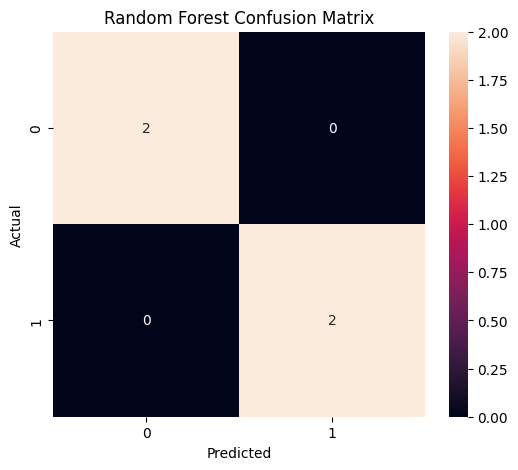

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [25]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
6,S1_Range,0.117033
7,S1_RMS,0.103951
4,S1_Minimum,0.090000
5,S1_Maximum,0.086222
9,S1_Peak_to_Peak,0.080000
18,S2_Maximum,0.074938
12,S1_Energy,0.074156
2,S1_Std,0.072424
8,S1_Peak,0.037951
19,S2_Range,0.034667


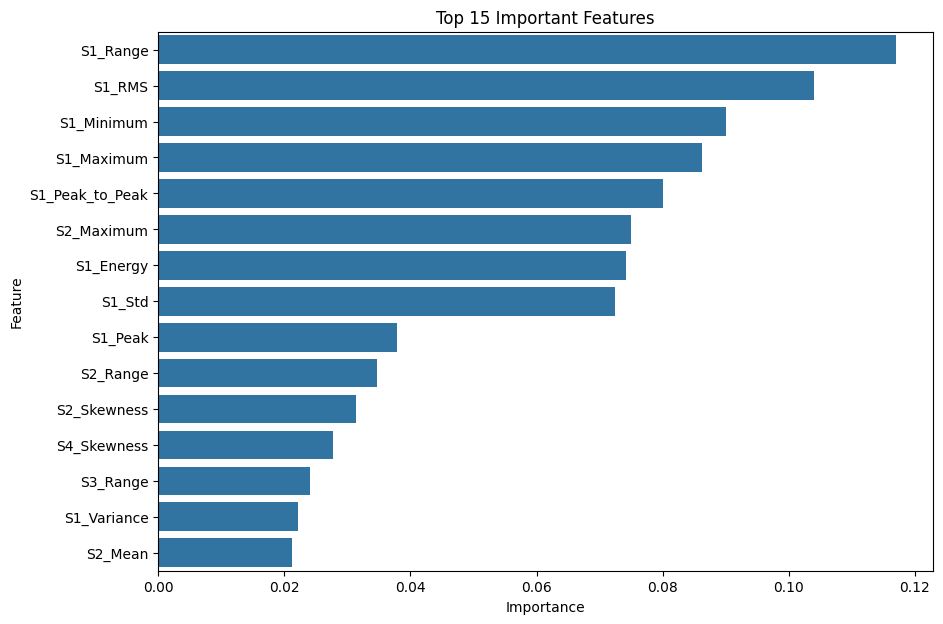

In [26]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.show()

In [27]:
importance["Sensor"] = importance["Feature"].str.extract(
    r"^(S\d+)"
)

sensor_importance = (
    importance
    .groupby("Sensor")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

print(sensor_importance)

Sensor
S1    0.711578
S2    0.186202
S3    0.057917
S4    0.044303
Name: Importance, dtype: float64


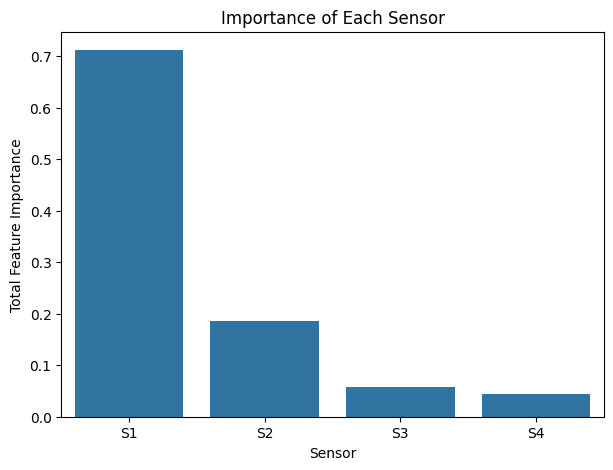

In [28]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=sensor_importance.index,
    y=sensor_importance.values
)

plt.xlabel("Sensor")
plt.ylabel("Total Feature Importance")
plt.title("Importance of Each Sensor")

plt.show()

In [30]:
import joblib

joblib.dump(rf, "gearbox_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']